# Dataset Overlap Analysis
## Our GitHub-Agentic-PR-Dataset vs. AIDev Dataset

This notebook compares two PR datasets from Hugging Face:
- **Ours**: `mabujadallah/GitHub-Agentic-PR-Dataset` → `all_pull_requests.parquet`
- **AIDev**: `hao-li/AIDev` → `all_pull_request.parquet`

We match PRs on `(repo_name, PR number)` since AIDev uses GraphQL node IDs while our collection uses REST API IDs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from huggingface_hub import hf_hub_download

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Datasets

In [ ]:
# Load our dataset
print("Loading our dataset (mabujadallah/GitHub-Agentic-PR-Dataset)...")
ours_path = hf_hub_download(
    repo_id="mabujadallah/GitHub-Agentic-PR-Dataset",
    filename="all_pull_requests.parquet",
    repo_type="dataset",
)
ours = pd.read_parquet(ours_path)
print(f"  Loaded: {len(ours):,} rows, {ours.shape[1]} columns")
print(f"  Columns: {list(ours.columns)}")

# Load AIDev dataset
print("\nLoading AIDev dataset (hao-li/AIDev)...")
aidev_path = hf_hub_download(
    repo_id="hao-li/AIDev",
    filename="all_pull_request.parquet",
    repo_type="dataset",
)
aidev = pd.read_parquet(aidev_path)
print(f"  Loaded: {len(aidev):,} rows, {aidev.shape[1]} columns")

Loading our dataset (mabujadallah/GitHub-Agentic-PR-Dataset)...
  Loaded: 1,959,649 rows, 16 columns
  Columns: ['id', 'number', 'title', 'body', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'repo_name', 'html_url', 'is_agent', 'agent']

Loading AIDev dataset (hao-li/AIDev)...
  Loaded: 932,791 rows, 14 columns
  Columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']


## 2. Prepare Match Keys
We normalize repository names and build a `(repo_name, pr_number)` match key.

In [20]:
# Remove OpenAI_Codex PRs from AIDev (not in our scope)
codex_count = (aidev["agent"] == "OpenAI_Codex").sum()
aidev = aidev[aidev["agent"] != "OpenAI_Codex"].reset_index(drop=True)
print(f"Removed {codex_count:,} OpenAI_Codex PRs from AIDev")
print(f"AIDev after filtering: {len(aidev):,} rows")
print(f"Remaining agents: {sorted(aidev['agent'].unique())}")

# Normalize repo names
if "repo_name" not in ours.columns and "repo_url" in ours.columns:
    ours["repo_name"] = ours["repo_url"].str.replace("https://api.github.com/repos/", "", regex=False)

if "repo_name" not in aidev.columns and "repo_url" in aidev.columns:
    aidev["repo_name"] = aidev["repo_url"].str.replace("https://api.github.com/repos/", "", regex=False)

# Ensure datetime
ours["created_at"] = pd.to_datetime(ours["created_at"], errors="coerce")
aidev["created_at"] = pd.to_datetime(aidev["created_at"], errors="coerce")

# Build match keys
ours["match_key"] = ours["repo_name"] + "#" + ours["number"].astype(str)
aidev["match_key"] = aidev["repo_name"] + "#" + aidev["number"].astype(str)

ours_keys = set(ours["match_key"])
aidev_keys = set(aidev["match_key"])

print(f"\nOur unique PRs:   {len(ours_keys):,}")
print(f"AIDev unique PRs: {len(aidev_keys):,}")

Removed 814,522 OpenAI_Codex PRs from AIDev
AIDev after filtering: 118,269 rows
Remaining agents: ['Claude_Code', 'Copilot', 'Cursor', 'Devin']

Our unique PRs:   1,959,648
AIDev unique PRs: 118,269


## 3. High-Level Overlap Statistics

In [21]:
overlap_keys = ours_keys & aidev_keys
ours_only_keys = ours_keys - aidev_keys
aidev_only_keys = aidev_keys - ours_keys

total_union = len(ours_keys | aidev_keys)
jaccard = len(overlap_keys) / total_union if total_union > 0 else 0

print("=" * 60)
print("HIGH-LEVEL OVERLAP")
print("=" * 60)
print(f"{'Our PRs (total):':<35} {len(ours_keys):>10,}")
print(f"{'AIDev PRs (total):':<35} {len(aidev_keys):>10,}")
print(f"{'Overlap (in both):':<35} {len(overlap_keys):>10,}")
print(f"{'Only in ours:':<35} {len(ours_only_keys):>10,}")
print(f"{'Only in AIDev:':<35} {len(aidev_only_keys):>10,}")
print(f"{'Union (all unique):':<35} {total_union:>10,}")
print(f"{'─' * 60}")
print(f"{'Overlap / Our total:':<35} {len(overlap_keys)/len(ours_keys)*100:>9.1f}%")
print(f"{'Overlap / AIDev total:':<35} {len(overlap_keys)/len(aidev_keys)*100:>9.1f}%")
print(f"{'Jaccard similarity:':<35} {jaccard:>9.4f}")

HIGH-LEVEL OVERLAP
Our PRs (total):                     1,959,648
AIDev PRs (total):                     118,269
Overlap (in both):                     101,742
Only in ours:                        1,857,906
Only in AIDev:                          16,527
Union (all unique):                  1,976,175
────────────────────────────────────────────────────────────
Overlap / Our total:                      5.2%
Overlap / AIDev total:                   86.0%
Jaccard similarity:                    0.0515


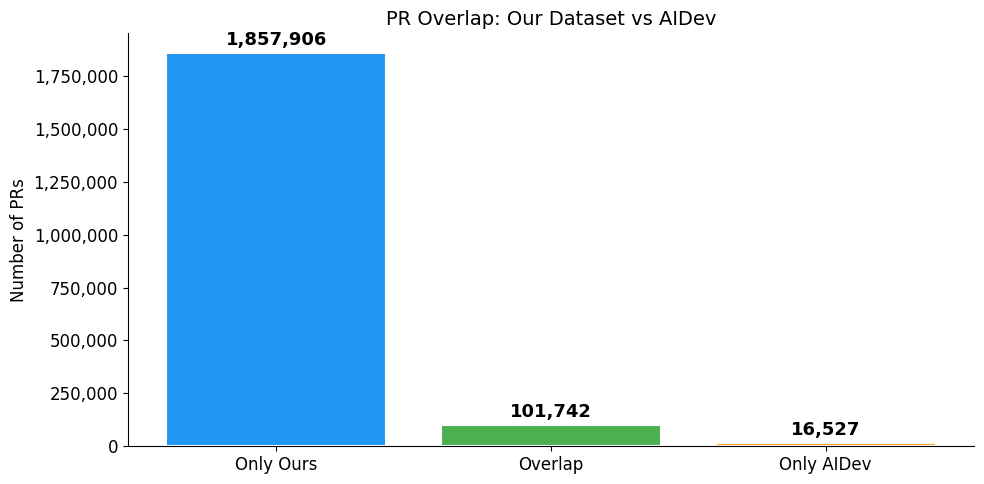

In [24]:
# Venn-style bar chart
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Only Ours', 'Overlap', 'Only AIDev']
values = [len(ours_only_keys), len(overlap_keys), len(aidev_only_keys)]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of PRs')
ax.set_title('PR Overlap: Our Dataset vs AIDev')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Overlap by Agent

In [25]:
# Tag overlap membership
ours["in_aidev"] = ours["match_key"].isin(aidev_keys)
aidev["in_ours"] = aidev["match_key"].isin(ours_keys)

# Our dataset by agent (exclude human)
ours_agents_only = ours[ours["agent"] != "human"]

print("=" * 70)
print("OUR DATASET — OVERLAP BREAKDOWN BY AGENT")
print("=" * 70)
ours_agent_stats = ours_agents_only.groupby("agent").agg(
    total=("match_key", "count"),
    in_aidev=("in_aidev", "sum"),
).astype(int)
ours_agent_stats["not_in_aidev"] = ours_agent_stats["total"] - ours_agent_stats["in_aidev"]
ours_agent_stats["overlap_pct"] = (ours_agent_stats["in_aidev"] / ours_agent_stats["total"] * 100).round(1)
ours_agent_stats = ours_agent_stats.sort_values("total", ascending=False)
print(ours_agent_stats.to_string())

# AIDev dataset by agent
print(f"\n{'=' * 70}")
print("AIDEV DATASET — OVERLAP BREAKDOWN BY AGENT")
print("=" * 70)
aidev_agent_stats = aidev.groupby("agent").agg(
    total=("match_key", "count"),
    in_ours=("in_ours", "sum"),
).astype(int)
aidev_agent_stats["not_in_ours"] = aidev_agent_stats["total"] - aidev_agent_stats["in_ours"]
aidev_agent_stats["overlap_pct"] = (aidev_agent_stats["in_ours"] / aidev_agent_stats["total"] * 100).round(1)
aidev_agent_stats = aidev_agent_stats.sort_values("total", ascending=False)
print(aidev_agent_stats.to_string())

OUR DATASET — OVERLAP BREAKDOWN BY AGENT
              total  in_aidev  not_in_aidev  overlap_pct
agent                                                   
Claude_Code  419965      3730        416235          0.9
Cursor       200166     26597        173569         13.3
Copilot      117863     44172         73691         37.5
Devin         35519     27226          8293         76.7

AIDEV DATASET — OVERLAP BREAKDOWN BY AGENT
             total  in_ours  not_in_ours  overlap_pct
agent                                                
Copilot      50447    44193         6254         87.6
Cursor       32941    26438         6503         80.3
Devin        29744    27226         2518         91.5
Claude_Code   5137     3885         1252         75.6


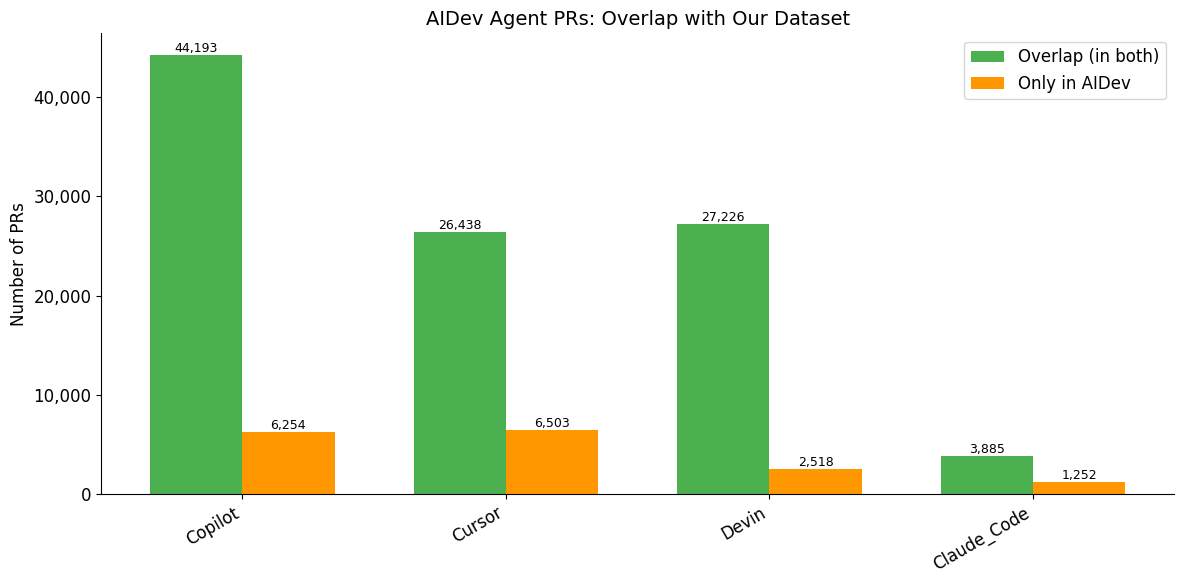

In [26]:
# Per-agent overlap chart (AIDev perspective)
fig, ax = plt.subplots(figsize=(12, 6))
agents = aidev_agent_stats.index.tolist()
x = np.arange(len(agents))
w = 0.35

bars1 = ax.bar(x - w/2, aidev_agent_stats["in_ours"], w, label="Overlap (in both)", color="#4CAF50")
bars2 = ax.bar(x + w/2, aidev_agent_stats["not_in_ours"], w, label="Only in AIDev", color="#FF9800")

ax.set_xticks(x)
ax.set_xticklabels(agents, rotation=30, ha='right')
ax.set_ylabel('Number of PRs')
ax.set_title('AIDev Agent PRs: Overlap with Our Dataset')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Overlap by Repository

In [27]:
# Repository-level comparison
ours_repos = set(ours["repo_name"].unique())
aidev_repos = set(aidev["repo_name"].unique())
shared_repos = ours_repos & aidev_repos
ours_only_repos = ours_repos - aidev_repos
aidev_only_repos = aidev_repos - ours_repos

print("=" * 60)
print("REPOSITORY OVERLAP")
print("=" * 60)
print(f"{'Our repos:':<35} {len(ours_repos):>8,}")
print(f"{'AIDev repos:':<35} {len(aidev_repos):>8,}")
print(f"{'Shared repos:':<35} {len(shared_repos):>8,}")
print(f"{'Only in ours:':<35} {len(ours_only_repos):>8,}")
print(f"{'Only in AIDev:':<35} {len(aidev_only_repos):>8,}")
print(f"{'─' * 60}")
print(f"{'Shared / Our repos:':<35} {len(shared_repos)/len(ours_repos)*100:>7.1f}%")
print(f"{'Shared / AIDev repos:':<35} {len(shared_repos)/len(aidev_repos)*100:>7.1f}%")

REPOSITORY OVERLAP
Our repos:                            29,312
AIDev repos:                          33,377
Shared repos:                         29,312
Only in ours:                              0
Only in AIDev:                         4,065
────────────────────────────────────────────────────────────
Shared / Our repos:                   100.0%
Shared / AIDev repos:                  87.8%


In [28]:
# Per-repo PR counts in shared repos
repo_ours = ours[ours["repo_name"].isin(shared_repos)].groupby("repo_name")["match_key"].nunique().rename("ours_prs")
repo_aidev = aidev[aidev["repo_name"].isin(shared_repos)].groupby("repo_name")["match_key"].nunique().rename("aidev_prs")
repo_overlap = (
    ours[ours["match_key"].isin(overlap_keys)]
    .groupby("repo_name")["match_key"].nunique().rename("overlap_prs")
)

repo_df = pd.DataFrame({"ours_prs": repo_ours, "aidev_prs": repo_aidev, "overlap_prs": repo_overlap}).fillna(0).astype(int)
repo_df["ours_only"] = repo_df["ours_prs"] - repo_df["overlap_prs"]
repo_df["aidev_only"] = repo_df["aidev_prs"] - repo_df["overlap_prs"]
repo_df["overlap_pct_ours"] = (repo_df["overlap_prs"] / repo_df["ours_prs"].replace(0, np.nan) * 100).round(1)
repo_df["overlap_pct_aidev"] = (repo_df["overlap_prs"] / repo_df["aidev_prs"].replace(0, np.nan) * 100).round(1)
repo_df = repo_df.sort_values("aidev_prs", ascending=False)

print(f"Top 20 shared repos by AIDev PR count:")
print(repo_df.head(20).to_string())

Top 20 shared repos by AIDev PR count:
                                 ours_prs  aidev_prs  overlap_prs  ours_only  aidev_only  overlap_pct_ours  overlap_pct_aidev
repo_name                                                                                                                    
drivly/ai                            1425        985          985        440           0              69.1              100.0
liam-hq/liam                         3695        352          352       3343           0               9.5              100.0
crewAIInc/crewAI                     2037        327          327       1710           0              16.1              100.0
dvargas92495/vargasjr-dev             629        245          245        384           0              39.0              100.0
stanleyrya/chunky-dad                1126        239          239        887           0              21.2              100.0
UltimatePea/chinese-ocaml             858        227          227        631   

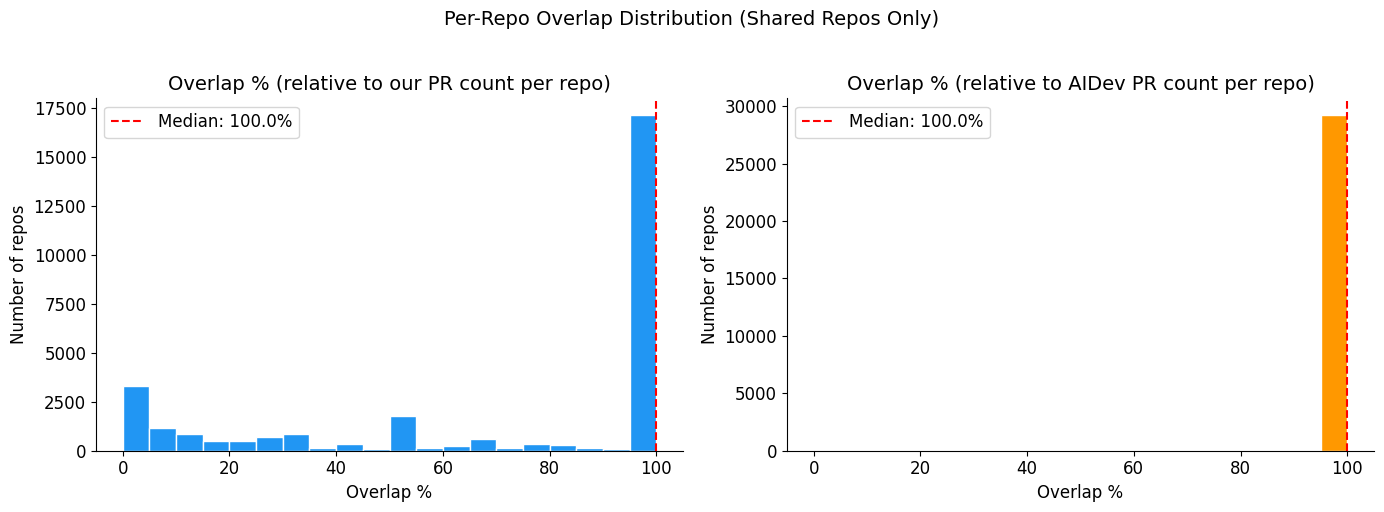

In [30]:
# Distribution of per-repo overlap percentage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(repo_df["overlap_pct_ours"].dropna(), bins=20, color='#2196F3', edgecolor='white')
axes[0].set_title('Overlap % (relative to our PR count per repo)')
axes[0].set_xlabel('Overlap %')
axes[0].set_ylabel('Number of repos')
axes[0].axvline(repo_df["overlap_pct_ours"].median(), color='red', linestyle='--', label=f'Median: {repo_df["overlap_pct_ours"].median():.1f}%')
axes[0].legend()

axes[1].hist(repo_df["overlap_pct_aidev"].dropna(), bins=20, color='#FF9800', edgecolor='white')
axes[1].set_title('Overlap % (relative to AIDev PR count per repo)')
axes[1].set_xlabel('Overlap %')
axes[1].set_ylabel('Number of repos')
axes[1].axvline(repo_df["overlap_pct_aidev"].median(), color='red', linestyle='--', label=f'Median: {repo_df["overlap_pct_aidev"].median():.1f}%')
axes[1].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Per-Repo Overlap Distribution (Shared Repos Only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Temporal Overlap (Monthly)

In [31]:
# Monthly breakdown
ours["month"] = ours["created_at"].dt.to_period("M")
aidev["month"] = aidev["created_at"].dt.to_period("M")

all_months = sorted(set(ours["month"].dropna()) | set(aidev["month"].dropna()))

monthly_rows = []
for m in all_months:
    o_m = set(ours[ours["month"] == m]["match_key"])
    a_m = set(aidev[aidev["month"] == m]["match_key"])
    overlap_m = o_m & a_m
    monthly_rows.append({
        "month": str(m),
        "ours_prs": len(o_m),
        "aidev_prs": len(a_m),
        "overlap": len(overlap_m),
        "ours_only": len(o_m - a_m),
        "aidev_only": len(a_m - o_m),
    })

monthly_df = pd.DataFrame(monthly_rows)
monthly_df["overlap_pct_ours"] = (monthly_df["overlap"] / monthly_df["ours_prs"].replace(0, np.nan) * 100).round(1)
monthly_df["overlap_pct_aidev"] = (monthly_df["overlap"] / monthly_df["aidev_prs"].replace(0, np.nan) * 100).round(1)

print(monthly_df.to_string(index=False))

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_43184\2779202895.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ours["month"] = ours["created_at"].dt.to_period("M")
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_43184\2779202895.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  aidev["month"] = aidev["created_at"].dt.to_period("M")


  month  ours_prs  aidev_prs  overlap  ours_only  aidev_only  overlap_pct_ours  overlap_pct_aidev
2024-12     85013        555      538      84475          17               0.6               96.9
2025-01     97746       2465     2386      95360          79               2.4               96.8
2025-02    103899       3311     3014     100885         297               2.9               91.0
2025-03    117487       3823     3592     113895         231               3.1               94.0
2025-04    116955       5509     5062     111893         447               4.3               91.9
2025-05    126436      12095    11013     115423        1082               8.7               91.1
2025-06    159086      24176    21320     137766        2856              13.4               88.2
2025-07    229281      66335    54698     174583       11637              23.9               82.5
2025-08    143626          0        0     143626           0               0.0                NaN
2025-09    131815   

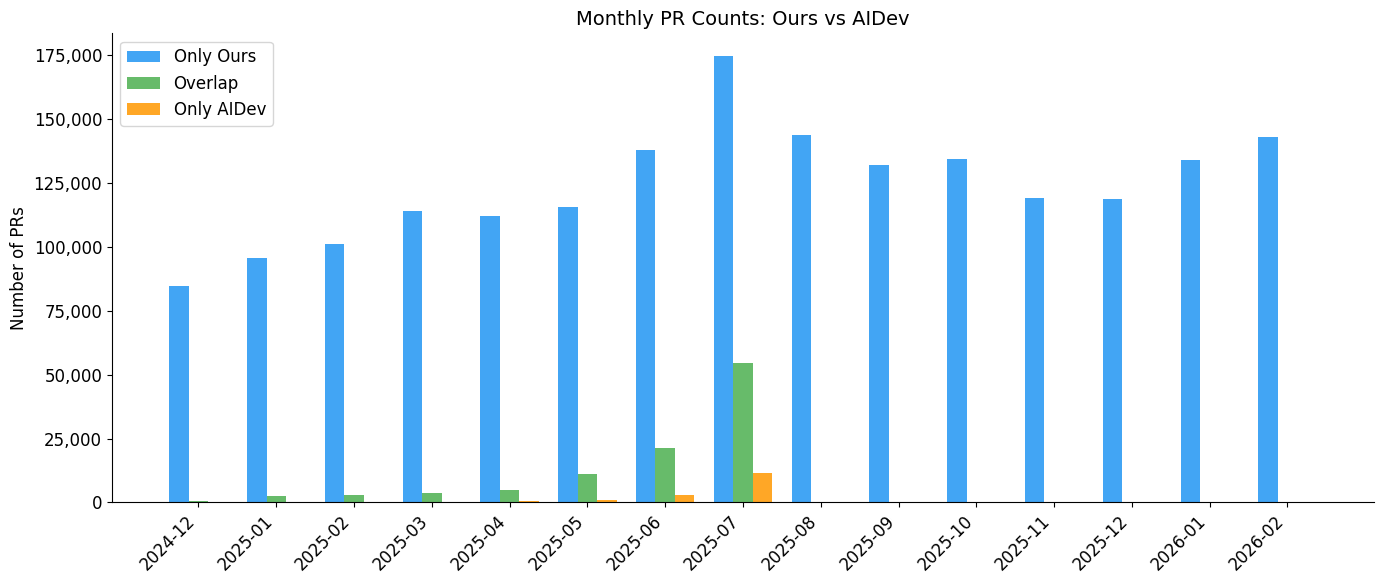

In [32]:
# Monthly trend chart
fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(monthly_df))
w = 0.25

ax1.bar(x - w, monthly_df["ours_only"], w, label="Only Ours", color="#2196F3", alpha=0.85)
ax1.bar(x, monthly_df["overlap"], w, label="Overlap", color="#4CAF50", alpha=0.85)
ax1.bar(x + w, monthly_df["aidev_only"], w, label="Only AIDev", color="#FF9800", alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(monthly_df["month"], rotation=45, ha="right")
ax1.set_ylabel("Number of PRs")
ax1.set_title("Monthly PR Counts: Ours vs AIDev")
ax1.legend(loc="upper left")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Agent-Level Cross-Tabulation

In [33]:
# For overlapping PRs, compare agent labels between the two datasets
ours_overlap = ours[ours["match_key"].isin(overlap_keys)][["match_key", "agent"]].rename(columns={"agent": "ours_agent"})
aidev_overlap = aidev[aidev["match_key"].isin(overlap_keys)][["match_key", "agent"]].rename(columns={"agent": "aidev_agent"})

# Drop duplicates to get one row per match_key per dataset
ours_overlap = ours_overlap.drop_duplicates(subset=["match_key"])
aidev_overlap = aidev_overlap.drop_duplicates(subset=["match_key"])

merged = ours_overlap.merge(aidev_overlap, on="match_key", how="inner")

print("=" * 60)
print("AGENT LABEL CROSS-TABULATION (Overlapping PRs)")
print("=" * 60)
ct = pd.crosstab(merged["ours_agent"], merged["aidev_agent"], margins=True, margins_name="Total")
print(ct.to_string())

# Agreement rate
agreement = (merged["ours_agent"] == merged["aidev_agent"]).sum()
print(f"\nAgent label agreement: {agreement:,} / {len(merged):,} ({agreement/len(merged)*100:.1f}%)")
print(f"Agent label mismatch:  {len(merged) - agreement:,} / {len(merged):,} ({(len(merged)-agreement)/len(merged)*100:.1f}%)")

AGENT LABEL CROSS-TABULATION (Overlapping PRs)
aidev_agent  Claude_Code  Copilot  Cursor  Devin   Total
ours_agent                                              
Claude_Code         3718        7       5      0    3730
Copilot                9    44157       4      2   44172
Cursor               147       28   26422      0   26597
Devin                  0        0       2  27224   27226
human                 11        1       5      0      17
Total               3885    44193   26438  27226  101742

Agent label agreement: 101,521 / 101,742 (99.8%)
Agent label mismatch:  221 / 101,742 (0.2%)


## 8. PR Status Comparison (Overlapping PRs)

In [34]:
# Compare PR state/merged status for overlapping PRs
state_cols_ours = [c for c in ["state", "merged"] if c in ours.columns]
state_cols_aidev = [c for c in ["state", "merged"] if c in aidev.columns]

if state_cols_ours and state_cols_aidev:
    ours_states = ours[ours["match_key"].isin(overlap_keys)][["match_key"] + state_cols_ours].drop_duplicates(subset=["match_key"])
    aidev_states = aidev[aidev["match_key"].isin(overlap_keys)][["match_key"] + state_cols_aidev].drop_duplicates(subset=["match_key"])
    
    ours_states.columns = ["match_key"] + [f"ours_{c}" for c in state_cols_ours]
    aidev_states.columns = ["match_key"] + [f"aidev_{c}" for c in state_cols_aidev]
    
    state_merged = ours_states.merge(aidev_states, on="match_key", how="inner")
    
    if "ours_state" in state_merged.columns and "aidev_state" in state_merged.columns:
        print("PR State Cross-Tabulation (Overlapping PRs):")
        print(pd.crosstab(state_merged["ours_state"], state_merged["aidev_state"], margins=True, margins_name="Total").to_string())
    
    if "ours_merged" in state_merged.columns and "aidev_merged" in state_merged.columns:
        print("\nMerged Status Cross-Tabulation (Overlapping PRs):")
        print(pd.crosstab(state_merged["ours_merged"], state_merged["aidev_merged"], margins=True, margins_name="Total").to_string())
else:
    print("State/merged columns not available in both datasets for comparison.")

PR State Cross-Tabulation (Overlapping PRs):
aidev_state  closed   open   Total
ours_state                        
closed        84812   3554   88366
open             20  13356   13376
Total         84832  16910  101742


## 9. What Does AIDev Have That We Don't? (And Vice Versa)

In [35]:
# AIDev-only PRs by agent
aidev_only = aidev[aidev["match_key"].isin(aidev_only_keys)]
ours_only = ours[ours["match_key"].isin(ours_only_keys)]

print("=" * 60)
print("AIDEV-ONLY PRs — Breakdown by Agent")
print("=" * 60)
aidev_only_agents = aidev_only["agent"].value_counts()
for agent, count in aidev_only_agents.items():
    print(f"  {agent:<20} {count:>8,}")
print(f"  {'TOTAL':<20} {len(aidev_only):>8,}")

print(f"\n{'=' * 60}")
print("OUR-ONLY PRs — Breakdown by Agent")
print("=" * 60)
ours_only_agents = ours_only["agent"].value_counts()
for agent, count in ours_only_agents.items():
    print(f"  {agent:<20} {count:>8,}")
print(f"  {'TOTAL':<20} {len(ours_only):>8,}")

AIDEV-ONLY PRs — Breakdown by Agent
  Cursor                  6,503
  Copilot                 6,254
  Devin                   2,518
  Claude_Code             1,252
  TOTAL                  16,527

OUR-ONLY PRs — Breakdown by Agent
  human                1,186,119
  Claude_Code           416,235
  Cursor                173,569
  Copilot                73,691
  Devin                   8,293
  TOTAL                1,857,907


In [36]:
# Time range of exclusive PRs
print("=" * 60)
print("TIME RANGES")
print("=" * 60)
print(f"Our dataset:        {ours['created_at'].min()} → {ours['created_at'].max()}")
print(f"AIDev dataset:      {aidev['created_at'].min()} → {aidev['created_at'].max()}")
print(f"Our-only PRs:       {ours_only['created_at'].min()} → {ours_only['created_at'].max()}")
print(f"AIDev-only PRs:     {aidev_only['created_at'].min()} → {aidev_only['created_at'].max()}")
print(f"Overlap PRs (ours): {ours[ours['match_key'].isin(overlap_keys)]['created_at'].min()} → {ours[ours['match_key'].isin(overlap_keys)]['created_at'].max()}")

TIME RANGES
Our dataset:        2024-12-01 00:03:14+00:00 → 2026-02-28 23:58:23+00:00
AIDev dataset:      2024-12-24 00:23:09+00:00 → 2025-07-30 19:39:22+00:00
Our-only PRs:       2024-12-01 00:03:14+00:00 → 2026-02-28 23:58:23+00:00
AIDev-only PRs:     2024-12-24 16:51:15+00:00 → 2025-07-30 19:39:22+00:00
Overlap PRs (ours): 2024-12-24 00:23:09+00:00 → 2026-02-21 00:08:33+00:00


In [37]:
# AIDev-only PRs by repo (top repos we're missing)
print("=" * 60)
print("TOP 20 REPOS WE'RE MISSING FROM AIDEV (by AIDev-only PR count)")
print("=" * 60)
aidev_only_by_repo = aidev_only.groupby("repo_name")["match_key"].nunique().sort_values(ascending=False)
for repo, count in aidev_only_by_repo.head(20).items():
    print(f"  {repo:<55} {count:>6,}")

print(f"\n{'=' * 60}")
print("TOP 20 REPOS UNIQUE TO OUR DATASET (by our-only PR count)")
print("=" * 60)
ours_only_by_repo = ours_only.groupby("repo_name")["match_key"].nunique().sort_values(ascending=False)
for repo, count in ours_only_by_repo.head(20).items():
    print(f"  {repo:<55} {count:>6,}")

TOP 20 REPOS WE'RE MISSING FROM AIDEV (by AIDev-only PR count)
  bolt-foundry/bolt-foundry                                  575
  antiwork/flexile                                           205
  rosssaunders/ccrxt                                         191
  mholzi/Soundbeats                                          190
  antiwork/helper                                            171
  mholzi/dashview                                            139
  kkarlsen06/wageCalculator                                  128
  abdifahadi/raabta                                          120
  gabriellagziel/appoint                                     112
  markus-lassfolk/rutos-starlink-failover                    110
  zhiro178/brainrot-gamer-stash                              106
  avgf3/abd                                                  101
  ramadhan22/dropship-erp                                    100
  amascaro08/FloHub                                           96
  venubhat23/react_marketic

## 10. Column Comparison

In [38]:
ours_cols = set(ours.columns)
aidev_cols = set(aidev.columns)
# Exclude our added helper columns
helper_cols = {"match_key", "in_aidev", "month"}
aidev_helper = {"match_key", "in_ours", "month", "repo_name"}
ours_real = ours_cols - helper_cols
aidev_real = aidev_cols - aidev_helper

shared_cols = sorted(ours_real & aidev_real)
ours_only_cols = sorted(ours_real - aidev_real)
aidev_only_cols = sorted(aidev_real - ours_real)

print("=" * 60)
print("COLUMN COMPARISON")
print("=" * 60)
print(f"\nShared columns ({len(shared_cols)}):")
for c in shared_cols:
    print(f"  {c}")
print(f"\nOnly in ours ({len(ours_only_cols)}):")
for c in ours_only_cols:
    print(f"  {c}")
print(f"\nOnly in AIDev ({len(aidev_only_cols)}):")
for c in aidev_only_cols:
    print(f"  {c}")

COLUMN COMPARISON

Shared columns (14):
  agent
  body
  closed_at
  created_at
  html_url
  id
  merged_at
  number
  repo_id
  repo_url
  state
  title
  user
  user_id

Only in ours (2):
  is_agent
  repo_name

Only in AIDev (0):


## 11. Summary Table

In [39]:
summary_data = {
    "Metric": [
        "Total PRs",
        "Unique Repos",
        "Agents Covered",
        "Date Range",
        "Columns",
    ],
    "Our Dataset": [
        f"{len(ours_keys):,}",
        f"{len(ours_repos):,}",
        ", ".join(sorted(ours['agent'].unique())),
        f"{ours['created_at'].min().strftime('%Y-%m-%d')} → {ours['created_at'].max().strftime('%Y-%m-%d')}",
        f"{len(ours_real)}",
    ],
    "AIDev Dataset": [
        f"{len(aidev_keys):,}",
        f"{len(aidev_repos):,}",
        ", ".join(sorted(aidev['agent'].unique())),
        f"{aidev['created_at'].min().strftime('%Y-%m-%d')} → {aidev['created_at'].max().strftime('%Y-%m-%d')}",
        f"{len(aidev_real)}",
    ],
}

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

print(f"\n{'=' * 60}")
print("FINAL OVERLAP SUMMARY")
print("=" * 60)
print(f"  PRs in both datasets:  {len(overlap_keys):,}")
print(f"  Only in ours:          {len(ours_only_keys):,}")
print(f"  Only in AIDev:         {len(aidev_only_keys):,}")
print(f"  Jaccard index:         {jaccard:.4f}")
print(f"  Our coverage of AIDev: {len(overlap_keys)/len(aidev_keys)*100:.1f}%")
print(f"  AIDev coverage of us:  {len(overlap_keys)/len(ours_keys)*100:.1f}%")

        Metric                                Our Dataset                       AIDev Dataset
     Total PRs                                  1,959,648                             118,269
  Unique Repos                                     29,312                              33,377
Agents Covered Claude_Code, Copilot, Cursor, Devin, human Claude_Code, Copilot, Cursor, Devin
    Date Range                    2024-12-01 → 2026-02-28             2024-12-24 → 2025-07-30
       Columns                                         16                                  14

FINAL OVERLAP SUMMARY
  PRs in both datasets:  101,742
  Only in ours:          1,857,906
  Only in AIDev:         16,527
  Jaccard index:         0.0515
  Our coverage of AIDev: 86.0%
  AIDev coverage of us:  5.2%


## 12. Human PR Overlap
Compare human PR parquet files between the two datasets.

In [40]:
# Load human PR datasets
print("Loading our human PRs...")
ours_human_path = hf_hub_download(
    repo_id="mabujadallah/GitHub-Agentic-PR-Dataset",
    filename="human_pull_requests.parquet",
    repo_type="dataset",
)
ours_human = pd.read_parquet(ours_human_path)
print(f"  Loaded: {len(ours_human):,} rows, {ours_human.shape[1]} columns")

print("\nLoading AIDev human PRs...")
aidev_human_path = hf_hub_download(
    repo_id="hao-li/AIDev",
    filename="human_pull_request.parquet",
    repo_type="dataset",
)
aidev_human = pd.read_parquet(aidev_human_path)
print(f"  Loaded: {len(aidev_human):,} rows, {aidev_human.shape[1]} columns")

# Normalize repo names
if "repo_name" not in ours_human.columns and "repo_url" in ours_human.columns:
    ours_human["repo_name"] = ours_human["repo_url"].str.replace("https://api.github.com/repos/", "", regex=False)
if "repo_name" not in aidev_human.columns and "repo_url" in aidev_human.columns:
    aidev_human["repo_name"] = aidev_human["repo_url"].str.replace("https://api.github.com/repos/", "", regex=False)

# Build match keys
ours_human["match_key"] = ours_human["repo_name"] + "#" + ours_human["number"].astype(str)
aidev_human["match_key"] = aidev_human["repo_name"] + "#" + aidev_human["number"].astype(str)

h_ours_keys = set(ours_human["match_key"])
h_aidev_keys = set(aidev_human["match_key"])
h_overlap = h_ours_keys & h_aidev_keys
h_ours_only = h_ours_keys - h_aidev_keys
h_aidev_only = h_aidev_keys - h_ours_keys
h_union = len(h_ours_keys | h_aidev_keys)
h_jaccard = len(h_overlap) / h_union if h_union > 0 else 0

print("\n" + "=" * 60)
print("HUMAN PR OVERLAP")
print("=" * 60)
print(f"{'Our human PRs:':<35} {len(h_ours_keys):>10,}")
print(f"{'AIDev human PRs:':<35} {len(h_aidev_keys):>10,}")
print(f"{'Overlap (in both):':<35} {len(h_overlap):>10,}")
print(f"{'Only in ours:':<35} {len(h_ours_only):>10,}")
print(f"{'Only in AIDev:':<35} {len(h_aidev_only):>10,}")
print(f"{'Union (all unique):':<35} {h_union:>10,}")
print(f"{'─' * 60}")
print(f"{'Overlap / Our total:':<35} {len(h_overlap)/len(h_ours_keys)*100:>9.1f}%")
print(f"{'Overlap / AIDev total:':<35} {len(h_overlap)/len(h_aidev_keys)*100:>9.1f}%")
print(f"{'Jaccard similarity:':<35} {h_jaccard:>9.4f}")

# Repository overlap
h_ours_repos = set(ours_human["repo_name"].unique())
h_aidev_repos = set(aidev_human["repo_name"].unique())
h_shared_repos = h_ours_repos & h_aidev_repos

print(f"\n{'=' * 60}")
print("HUMAN PR — REPOSITORY OVERLAP")
print("=" * 60)
print(f"{'Our repos:':<35} {len(h_ours_repos):>8,}")
print(f"{'AIDev repos:':<35} {len(h_aidev_repos):>8,}")
print(f"{'Shared repos:':<35} {len(h_shared_repos):>8,}")
print(f"{'Only in ours:':<35} {len(h_ours_repos - h_aidev_repos):>8,}")
print(f"{'Only in AIDev:':<35} {len(h_aidev_repos - h_ours_repos):>8,}")

# Time ranges
ours_human["created_at"] = pd.to_datetime(ours_human["created_at"], errors="coerce")
aidev_human["created_at"] = pd.to_datetime(aidev_human["created_at"], errors="coerce")
print(f"\n{'=' * 60}")
print("HUMAN PR — TIME RANGES")
print("=" * 60)
print(f"Our human PRs:    {ours_human['created_at'].min()} → {ours_human['created_at'].max()}")
print(f"AIDev human PRs:  {aidev_human['created_at'].min()} → {aidev_human['created_at'].max()}")

Loading our human PRs...


c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mahmoudabujadallah\.cache\huggingface\hub\datasets--mabujadallah--GitHub-Agentic-PR-Dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  Loaded: 1,186,136 rows, 16 columns

Loading AIDev human PRs...


c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mahmoudabujadallah\.cache\huggingface\hub\datasets--hao-li--AIDev. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  Loaded: 6,618 rows, 13 columns

HUMAN PR OVERLAP
Our human PRs:                       1,186,135
AIDev human PRs:                         6,618
Overlap (in both):                       3,799
Only in ours:                        1,182,336
Only in AIDev:                           2,819
Union (all unique):                  1,188,954
────────────────────────────────────────────────────────────
Overlap / Our total:                      0.3%
Overlap / AIDev total:                   57.4%
Jaccard similarity:                    0.0032

HUMAN PR — REPOSITORY OVERLAP
Our repos:                             1,640
AIDev repos:                             818
Shared repos:                            468
Only in ours:                          1,172
Only in AIDev:                           350

HUMAN PR — TIME RANGES
Our human PRs:    2024-12-01 00:03:14+00:00 → 2026-02-28 23:58:23+00:00
AIDev human PRs:  2025-01-01 00:22:59+00:00 → 2025-06-28 19:44:33+00:00


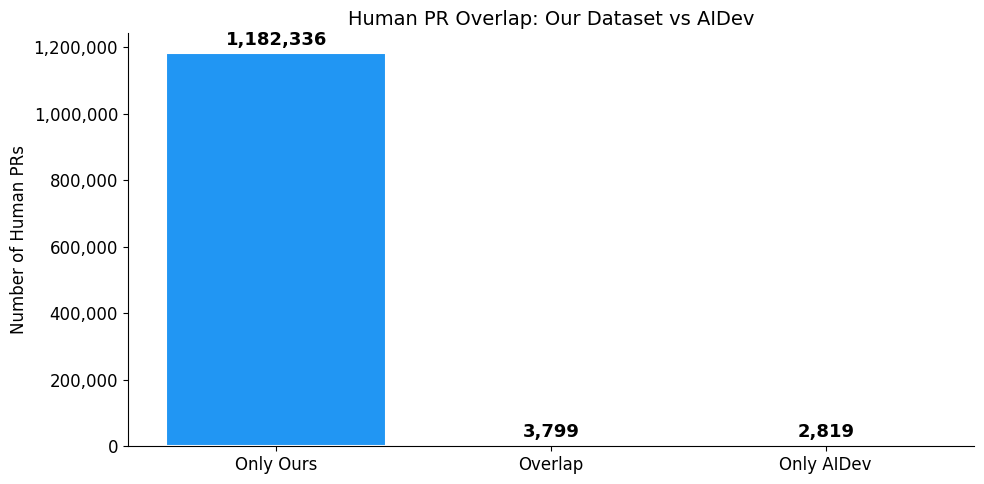

In [41]:
# Human PR overlap bar chart
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Only Ours', 'Overlap', 'Only AIDev']
values = [len(h_ours_only), len(h_overlap), len(h_aidev_only)]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Human PRs')
ax.set_title('Human PR Overlap: Our Dataset vs AIDev')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 13. Apple-to-Apple Comparison (Same Repos, Same Time Range, No Codex)

We restrict **both** datasets to:
- Only the **shared repositories** (repos present in both datasets)
- Only the **AIDev time range** (exclude our months beyond AIDev's last date)
- AIDev already has Codex removed

This isolates the true coverage question: *does our data fully cover AIDev (without Codex)?*

In [42]:
# ── Determine the overlapping time window ──
aidev_max_date = aidev["created_at"].max()
aidev_min_date = aidev["created_at"].min()
print(f"AIDev time range: {aidev_min_date} → {aidev_max_date}")

# Shared repos (from all_pull_requests, already computed)
shared_repos_all = ours_repos & aidev_repos
print(f"Shared repos (all PRs): {len(shared_repos_all):,}")

# ── Filter our data to same time range + same repos ──
ours_matched = ours[
    (ours["repo_name"].isin(shared_repos_all)) &
    (ours["created_at"] >= aidev_min_date) &
    (ours["created_at"] <= aidev_max_date) &
    (ours["agent"] != "human")
].copy()

aidev_matched = aidev[
    aidev["repo_name"].isin(shared_repos_all)
].copy()

# Also filter human PRs to same scope
ours_human_matched = ours_human[
    (ours_human["repo_name"].isin(h_shared_repos)) &
    (ours_human["created_at"] >= aidev_min_date) &
    (ours_human["created_at"] <= aidev_max_date)
].copy()

aidev_human_matched = aidev_human[
    aidev_human["repo_name"].isin(h_shared_repos)
].copy()

print(f"\nAfter filtering to shared repos + AIDev time range:")
print(f"  Our agent PRs:     {len(ours_matched):,}")
print(f"  AIDev agent PRs:   {len(aidev_matched):,}")
print(f"  Our human PRs:     {len(ours_human_matched):,}")
print(f"  AIDev human PRs:   {len(aidev_human_matched):,}")

AIDev time range: 2024-12-24 00:23:09+00:00 → 2025-07-30 19:39:22+00:00
Shared repos (all PRs): 29,312

After filtering to shared repos + AIDev time range:
  Our agent PRs:     396,291
  AIDev agent PRs:   102,031
  Our human PRs:     282,239
  AIDev human PRs:   4,929


In [43]:
# ── Agent PR overlap (same repos, same time range) ──
ours_matched["match_key"] = ours_matched["repo_name"] + "#" + ours_matched["number"].astype(str)
aidev_matched["match_key"] = aidev_matched["repo_name"] + "#" + aidev_matched["number"].astype(str)

m_ours_keys = set(ours_matched["match_key"])
m_aidev_keys = set(aidev_matched["match_key"])
m_overlap = m_ours_keys & m_aidev_keys
m_ours_only = m_ours_keys - m_aidev_keys
m_aidev_only = m_aidev_keys - m_ours_keys

print("=" * 70)
print("AGENT PR COVERAGE (Same Repos, Same Time Range, No Codex)")
print("=" * 70)
print(f"{'Our agent PRs:':<40} {len(m_ours_keys):>10,}")
print(f"{'AIDev agent PRs:':<40} {len(m_aidev_keys):>10,}")
print(f"{'Overlap:':<40} {len(m_overlap):>10,}")
print(f"{'Only in ours:':<40} {len(m_ours_only):>10,}")
print(f"{'Only in AIDev:':<40} {len(m_aidev_only):>10,}")
print(f"{'─' * 70}")
print(f"{'We cover of AIDev agent PRs:':<40} {len(m_overlap)/len(m_aidev_keys)*100:>9.1f}%")
print(f"{'AIDev covers of our agent PRs:':<40} {len(m_overlap)/len(m_ours_keys)*100:>9.1f}%")

# Per-agent breakdown
print(f"\n{'=' * 70}")
print("PER-AGENT COVERAGE OF AIDEV (Same Repos, Same Time Range)")
print("=" * 70)
for ag in sorted(aidev_matched["agent"].unique()):
    ag_keys = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"])
    covered = len(ag_keys & m_ours_keys)
    missed = len(ag_keys - m_ours_keys)
    pct = covered / len(ag_keys) * 100 if ag_keys else 0
    print(f"  {ag:<15}  AIDev: {len(ag_keys):>7,}  Covered: {covered:>7,}  Missed: {missed:>6,}  Coverage: {pct:>5.1f}%")

# ── Human PR overlap (same repos, same time range) ──
ours_human_matched["match_key"] = ours_human_matched["repo_name"] + "#" + ours_human_matched["number"].astype(str)
aidev_human_matched["match_key"] = aidev_human_matched["repo_name"] + "#" + aidev_human_matched["number"].astype(str)

mh_ours_keys = set(ours_human_matched["match_key"])
mh_aidev_keys = set(aidev_human_matched["match_key"])
mh_overlap = mh_ours_keys & mh_aidev_keys
mh_ours_only = mh_ours_keys - mh_aidev_keys
mh_aidev_only = mh_aidev_keys - mh_ours_keys

print(f"\n{'=' * 70}")
print("HUMAN PR COVERAGE (Same Repos, Same Time Range)")
print("=" * 70)
print(f"{'Our human PRs:':<40} {len(mh_ours_keys):>10,}")
print(f"{'AIDev human PRs:':<40} {len(mh_aidev_keys):>10,}")
print(f"{'Overlap:':<40} {len(mh_overlap):>10,}")
print(f"{'Only in ours:':<40} {len(mh_ours_only):>10,}")
print(f"{'Only in AIDev:':<40} {len(mh_aidev_only):>10,}")
print(f"{'─' * 70}")
print(f"{'We cover of AIDev human PRs:':<40} {len(mh_overlap)/len(mh_aidev_keys)*100:>9.1f}%")
print(f"{'AIDev covers of our human PRs:':<40} {len(mh_overlap)/len(mh_ours_keys)*100:>9.1f}%")

AGENT PR COVERAGE (Same Repos, Same Time Range, No Codex)
Our agent PRs:                              396,291
AIDev agent PRs:                            102,031
Overlap:                                    101,606
Only in ours:                               294,685
Only in AIDev:                                  425
──────────────────────────────────────────────────────────────────────
We cover of AIDev agent PRs:                  99.6%
AIDev covers of our agent PRs:                25.6%

PER-AGENT COVERAGE OF AIDEV (Same Repos, Same Time Range)
  Claude_Code      AIDev:   3,940  Covered:   3,863  Missed:     77  Coverage:  98.0%
  Copilot          AIDev:  44,272  Covered:  44,144  Missed:    128  Coverage:  99.7%
  Cursor           AIDev:  26,554  Covered:  26,402  Missed:    152  Coverage:  99.4%
  Devin            AIDev:  27,265  Covered:  27,197  Missed:     68  Coverage:  99.8%

HUMAN PR COVERAGE (Same Repos, Same Time Range)
Our human PRs:                              282,239
AID

In [44]:
# ── Explain the differences ──
print("=" * 70)
print("WHY ARE THERE DIFFERENCES?")
print("=" * 70)

# 1. AIDev-only agent PRs — what repos are they in?
aidev_only_matched = aidev_matched[aidev_matched["match_key"].isin(m_aidev_only)]
if len(aidev_only_matched) > 0:
    print(f"\n1. AIDev agent PRs we MISSED ({len(m_aidev_only):,} PRs):")
    missed_by_repo = aidev_only_matched.groupby("repo_name")["match_key"].nunique().sort_values(ascending=False)
    print(f"   Spread across {len(missed_by_repo):,} repos")
    print(f"   Top 10 repos with most missed PRs:")
    for repo, cnt in missed_by_repo.head(10).items():
        print(f"     {repo:<50} {cnt:>5,}")
    
    print(f"\n   Missed by agent:")
    for ag, cnt in aidev_only_matched["agent"].value_counts().items():
        print(f"     {ag:<15} {cnt:>7,}")
    
    # Check if missed PRs are in repos we have but with different numbers
    missed_repos_we_have = set(aidev_only_matched["repo_name"]) & set(ours_matched["repo_name"])
    missed_repos_we_dont = set(aidev_only_matched["repo_name"]) - set(ours_matched["repo_name"])
    print(f"\n   Repos where we have SOME agent PRs but missed these: {len(missed_repos_we_have):,}")
    print(f"   Repos we have NO agent PRs for at all:               {len(missed_repos_we_dont):,}")

# 2. Our-only agent PRs — what are they?
ours_only_matched = ours_matched[ours_matched["match_key"].isin(m_ours_only)]
if len(ours_only_matched) > 0:
    print(f"\n2. Our agent PRs NOT in AIDev ({len(m_ours_only):,} PRs):")
    extra_by_repo = ours_only_matched.groupby("repo_name")["match_key"].nunique().sort_values(ascending=False)
    print(f"   Spread across {len(extra_by_repo):,} repos")
    
    print(f"\n   Our extra PRs by agent:")
    for ag, cnt in ours_only_matched["agent"].value_counts().items():
        print(f"     {ag:<15} {cnt:>7,}")
    
    print(f"\n   Likely reasons for our extra PRs:")
    print(f"   - We collect ALL PRs (state=all) then classify agents; AIDev may filter differently")
    print(f"   - Different agent detection heuristics (username vs commit signature vs bot label)")
    print(f"   - PR state changes between collection times (open→closed, labels added/removed)")

# 3. Human PR differences
if len(mh_aidev_only) > 0:
    print(f"\n3. AIDev human PRs we MISSED ({len(mh_aidev_only):,} PRs):")
    print(f"   Same root causes as agent PRs — different collection scope & timing")
if len(mh_ours_only) > 0:
    print(f"\n4. Our human PRs NOT in AIDev ({len(mh_ours_only):,} PRs):")
    print(f"   We collect all PRs from each repo; AIDev may sample or filter differently")

WHY ARE THERE DIFFERENCES?

1. AIDev agent PRs we MISSED (425 PRs):
   Spread across 136 repos
   Top 10 repos with most missed PRs:
     EvilEvan/MathMaster                                   29
     Devin-Workshop/insurance-analytics                    28
     COG-GTM/cypress-realworld-app                         25
     KnightNiwrem/Digital-Pets                             17
     EvilEvan/Wild-animals                                  9
     williamjmorenor/now-lms                                9
     arthur-debert/txxt                                     8
     COG-GTM/nodejs-goof                                    8
     daveio/dave-io                                         8
     nagiyu/freshness-notifier                              7

   Missed by agent:
     Cursor              152
     Copilot             128
     Claude_Code          77
     Devin                68

   Repos where we have SOME agent PRs but missed these: 57
   Repos we have NO agent PRs for at all:         

In [45]:
# ══════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════

# Totals for the matched scope
ours_agent_total = len(m_ours_keys)
ours_human_total = len(mh_ours_keys)
ours_all_total = ours_agent_total + ours_human_total

aidev_agent_total = len(m_aidev_keys)
aidev_human_total = len(mh_aidev_keys)
aidev_all_total = aidev_agent_total + aidev_human_total

overlap_agent = len(m_overlap)
overlap_human = len(mh_overlap)
overlap_all = overlap_agent + overlap_human

rows = []
rows.append({
    "Category": "Agent PRs",
    "Our Dataset": f"{ours_agent_total:,}",
    "AIDev (no Codex)": f"{aidev_agent_total:,}",
    "Overlap": f"{overlap_agent:,}",
    "We Cover AIDev": f"{overlap_agent/aidev_agent_total*100:.1f}%" if aidev_agent_total else "N/A",
    "AIDev Covers Us": f"{overlap_agent/ours_agent_total*100:.1f}%" if ours_agent_total else "N/A",
})

# Per agent rows
for ag in sorted(set(aidev_matched["agent"].unique()) | set(ours_matched["agent"].unique())):
    ag_ours = set(ours_matched[ours_matched["agent"] == ag]["match_key"]) if ag in ours_matched["agent"].values else set()
    ag_aidev = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"]) if ag in aidev_matched["agent"].values else set()
    ag_overlap = ag_ours & ag_aidev
    rows.append({
        "Category": f"  └ {ag}",
        "Our Dataset": f"{len(ag_ours):,}",
        "AIDev (no Codex)": f"{len(ag_aidev):,}",
        "Overlap": f"{len(ag_overlap):,}",
        "We Cover AIDev": f"{len(ag_overlap)/len(ag_aidev)*100:.1f}%" if ag_aidev else "N/A",
        "AIDev Covers Us": f"{len(ag_overlap)/len(ag_ours)*100:.1f}%" if ag_ours else "N/A",
    })

rows.append({
    "Category": "Human PRs",
    "Our Dataset": f"{ours_human_total:,}",
    "AIDev (no Codex)": f"{aidev_human_total:,}",
    "Overlap": f"{overlap_human:,}",
    "We Cover AIDev": f"{overlap_human/aidev_human_total*100:.1f}%" if aidev_human_total else "N/A",
    "AIDev Covers Us": f"{overlap_human/ours_human_total*100:.1f}%" if ours_human_total else "N/A",
})

rows.append({
    "Category": "─" * 20,
    "Our Dataset": "─" * 10,
    "AIDev (no Codex)": "─" * 10,
    "Overlap": "─" * 10,
    "We Cover AIDev": "─" * 10,
    "AIDev Covers Us": "─" * 10,
})

rows.append({
    "Category": "TOTAL (Agent+Human)",
    "Our Dataset": f"{ours_all_total:,}",
    "AIDev (no Codex)": f"{aidev_all_total:,}",
    "Overlap": f"{overlap_all:,}",
    "We Cover AIDev": f"{overlap_all/aidev_all_total*100:.1f}%" if aidev_all_total else "N/A",
    "AIDev Covers Us": f"{overlap_all/ours_all_total*100:.1f}%" if ours_all_total else "N/A",
})

final_table = pd.DataFrame(rows)

print("=" * 100)
print("FINAL SUMMARY — Same Repos, Same Time Range, No Codex")
print("=" * 100)
print(final_table.to_string(index=False))
print(f"\nScope: {len(shared_repos_all):,} shared repos, {aidev_min_date.strftime('%Y-%m-%d')} → {aidev_max_date.strftime('%Y-%m-%d')}")

FINAL SUMMARY — Same Repos, Same Time Range, No Codex
            Category Our Dataset AIDev (no Codex)    Overlap We Cover AIDev AIDev Covers Us
           Agent PRs     396,291          102,031    101,606          99.6%           25.6%
       └ Claude_Code     197,160            3,940      3,710          94.2%            1.9%
           └ Copilot      59,350           44,272     44,118          99.7%           74.3%
            └ Cursor     112,581           26,554     26,400          99.4%           23.4%
             └ Devin      27,200           27,265     27,197          99.8%          100.0%
           Human PRs     282,239            4,929      3,799          77.1%            1.3%
────────────────────  ──────────       ────────── ──────────     ──────────      ──────────
 TOTAL (Agent+Human)     678,530          106,960    105,405          98.5%           15.5%

Scope: 29,312 shared repos, 2024-12-24 → 2025-07-30


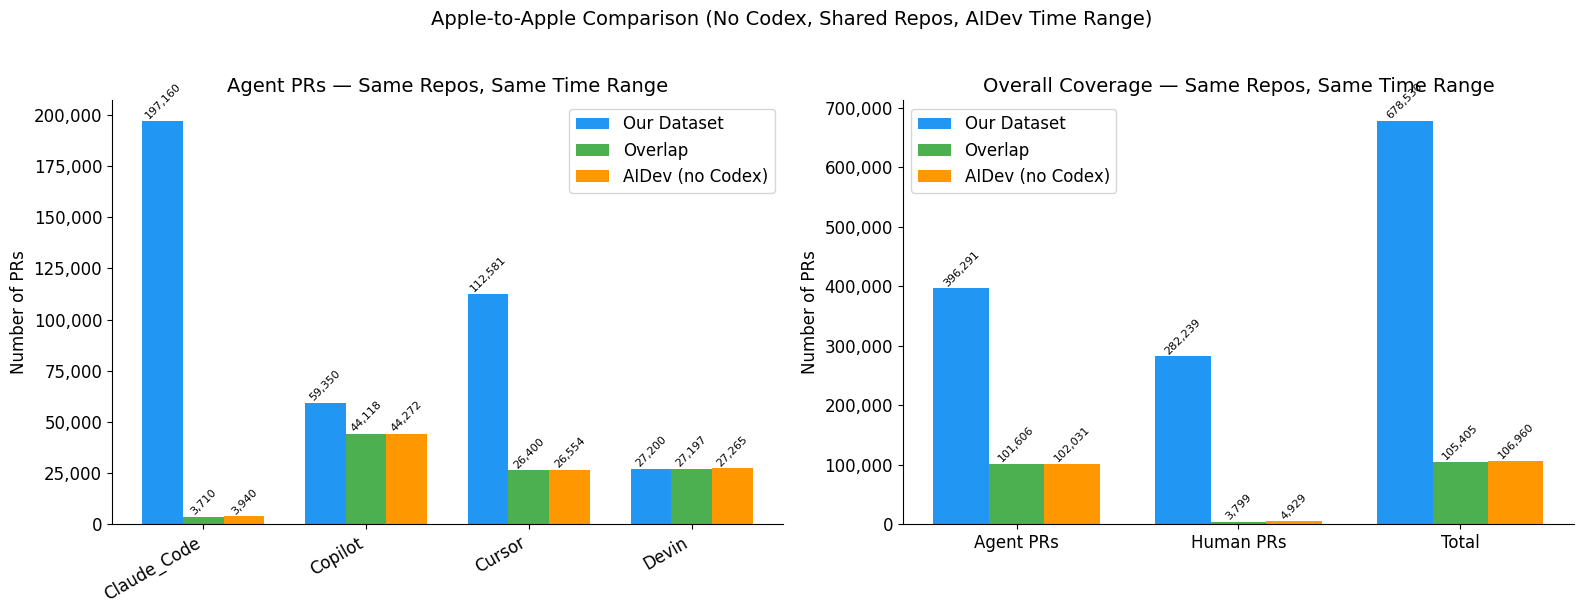

In [46]:
# ── Visual: side-by-side coverage bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Agent PRs
agent_labels = sorted(set(aidev_matched["agent"].unique()) | set(ours_matched["agent"].unique()))
ag_ours_vals, ag_aidev_vals, ag_overlap_vals = [], [], []
for ag in agent_labels:
    ag_o = set(ours_matched[ours_matched["agent"] == ag]["match_key"]) if ag in ours_matched["agent"].values else set()
    ag_a = set(aidev_matched[aidev_matched["agent"] == ag]["match_key"]) if ag in aidev_matched["agent"].values else set()
    ag_ours_vals.append(len(ag_o))
    ag_aidev_vals.append(len(ag_a))
    ag_overlap_vals.append(len(ag_o & ag_a))

x = np.arange(len(agent_labels))
w = 0.25
axes[0].bar(x - w, ag_ours_vals, w, label="Our Dataset", color="#2196F3")
axes[0].bar(x, ag_overlap_vals, w, label="Overlap", color="#4CAF50")
axes[0].bar(x + w, ag_aidev_vals, w, label="AIDev (no Codex)", color="#FF9800")
axes[0].set_xticks(x)
axes[0].set_xticklabels(agent_labels, rotation=30, ha="right")
axes[0].set_ylabel("Number of PRs")
axes[0].set_title("Agent PRs — Same Repos, Same Time Range")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)

# Overall: Agent vs Human vs Total
cats = ["Agent PRs", "Human PRs", "Total"]
ours_vals = [ours_agent_total, ours_human_total, ours_all_total]
aidev_vals = [aidev_agent_total, aidev_human_total, aidev_all_total]
ovlp_vals = [overlap_agent, overlap_human, overlap_all]

x2 = np.arange(len(cats))
axes[1].bar(x2 - w, ours_vals, w, label="Our Dataset", color="#2196F3")
axes[1].bar(x2, ovlp_vals, w, label="Overlap", color="#4CAF50")
axes[1].bar(x2 + w, aidev_vals, w, label="AIDev (no Codex)", color="#FF9800")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cats)
axes[1].set_ylabel("Number of PRs")
axes[1].set_title("Overall Coverage — Same Repos, Same Time Range")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top', 'right']].set_visible(False)

for ax_i in axes:
    for container in ax_i.containers:
        for bar in container:
            h = bar.get_height()
            if h > 0:
                ax_i.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}',
                         ha='center', va='bottom', fontsize=8, rotation=45)

plt.suptitle("Apple-to-Apple Comparison (No Codex, Shared Repos, AIDev Time Range)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()